# Errori, fallimenti e altre piaghe

"Tutto ciò che può andare storto, andrà storto."
Questa è la legge di Murphy, e funziona ovunque e sempre. Anche l'esecuzione del tuo codice può andare storta. E se può succedere, succederà.

Gli errori sono il pane quotidiano di chiunque scriva codice. In Python, quando si verifica un problema insormontabile durante l'esecuzione, il programma non si limita a bloccarsi in silenzio, ma solleva un'**eccezione**, interrompendo il flusso lineare del codice a meno che non venga opportunamente gestita.

Dai un'occhiata al codice nell'editor. Ci sono almeno due modi diversi in cui può "andare storto" e causare il crash del programma. Riesci a individuarli?

In [3]:
import math

#x = float(input("Enter x: "))
x = 16
y = math.sqrt(x)

print("The square root of", x, "equals to", y)

The square root of 16 equals to 4.0


Dato che l'utente può inserire una stringa di caratteri completamente arbitraria, non c'è alcuna garanzia che questa possa essere convertita in un valore float: questa è la prima vulnerabilità del codice.

La seconda è che la funzione `sqrt()` fallisce se riceve un argomento negativo.
Potresti imbatterti in uno dei seguenti messaggi di errore.

Qualcosa del genere:

```text
Output
Enter x: Abracadabra
 
Traceback (most recent call last):
 
  File "sqrt.py", line 3, in <module>
 
    x = float(input("Enter x: "))
 
ValueError: could not convert string to float: 'Abracadabra'

```

Oppure qualcosa del genere:

```text
Output
Enter x: -1
 
Traceback (most recent call last):
 
  File "sqrt.py", line 4, in <module>
 
    y = math.sqrt(x)
 
ValueError: math domain error

```

Puoi proteggerti da simili sorprese? Certamente sì. Inoltre, devi farlo per poter essere considerato un buon programmatore.

# Le eccezioni (*Exceptions*)

Ogni volta che il tuo codice tenta di fare qualcosa di sbagliato, insensato, irresponsabile o semplicemente irrealizzabile, Python fa due cose:

1. Interrompe l'esecuzione del programma.
2. Crea un tipo speciale di dato, chiamato **eccezione**.

Entrambe queste attività vengono definite **sollevare un'eccezione** (*raising an exception*). Possiamo dire che Python solleva sempre un'eccezione (o che un'eccezione è stata lanciata) quando non ha la più pallida idea di come procedere con l'esecuzione del tuo codice.

Cosa succede subito dopo?

* L'eccezione appena sollevata "si aspetta" che qualcuno o qualcosa se ne accorga e se ne prenda cura.
* Se non interviene nulla a gestire l'eccezione sollevata, il programma viene **terminato forzatamente** e vedrai apparire sulla console un messaggio di errore generato da Python.
* Al contrario, se l'eccezione viene presa in carico e gestita correttamente, il programma sospeso può essere ripristinato e la sua esecuzione può continuare in totale sicurezza.

Python mette a disposizione degli strumenti efficaci che ti permettono di osservare le eccezioni, identificarle e gestirle in modo efficiente. Questo è possibile grazie al fatto che tutte le potenziali eccezioni hanno un loro **nome univoco**: in questo modo puoi categorizzarle e reagire in modo appropriato a seconda del problema.

Conosci già alcuni nomi di eccezioni. Dai un'occhiata a questo messaggio diagnostico:

```text
Output
ValueError: math domain error

```

La parola evidenziata qui sopra (`ValueError`) è proprio il nome dell'eccezione. Impariamo a conoscere anche altre eccezioni.

Dai un'occhiata al codice nell'editor ed esegui questo programma (chiaramente errato).

```python
value = 1
value /= 0
```
Il messaggio di errore che otterrai sarà simile a questo:

```text
Traceback (most recent call last):
    File "divide_by_zero.py", line 2, in <module>
        value /= 0
ZeroDivisionError: division by zero
```

Il nome dell'eccezione in questo caso è `ZeroDivisionError`, e come puoi intuire, viene sollevata ogni volta che si tenta di dividere un numero per zero.

Dai un'occhiata al codice nell'editor. Cosa succederà quando lo esegui? Verifica.

```python
my_list = []
x = my_list[0]

```

In risposta vedrai comparire il seguente messaggio:

```text
Output
Traceback (most recent call last):
File "lst.py", line 2, in <module>
x = my_list[0]
IndexError: list index out of range

```

Questo è l'**`IndexError`**.

Come si gestiscono le eccezioni? La parola **`try`** è la chiave per risolvere il problema. Inoltre, si tratta proprio di una parola chiave (*keyword*) del linguaggio.

La ricetta per il successo è la seguente:

1. Per prima cosa, devi *provare* (`try`) a fare qualcosa.
2. Subito dopo, devi verificare se tutto è andato per il verso giusto.

Ma non sarebbe meglio controllare prima tutte le circostanze e fare qualcosa solo se è sicuro?
Proprio come nell'esempio che vedi nell'editor.

In [4]:
first_number = int(input("Enter the first number: "))
second_number = int(input("Enter the second number: "))

if second_number != 0:
    print(first_number / second_number)
else:
    print("This operation cannot be done.")

print("THE END.")
    

This operation cannot be done.
THE END.


Bisogna ammetterlo: questo modo di procedere può sembrare il più naturale e comprensibile, ma in realtà non semplifica affatto la vita a chi programma. Tutti questi controlli preventivi rischiano di rendere il codice gonfio, ridondante e difficile da leggere.

Python preferisce un approccio completamente diverso, spesso riassunto dal principio *"È più facile chiedere perdono che chiedere il permesso"* (EAFP - *Easier to ask for forgiveness than permission*).

Dai un'occhiata al codice nell'editor: questo è l'approccio preferito in Python.

In [5]:
first_number = int(input("Enter the first number: "))
second_number = int(input("Enter the second number: "))

try:
    print(first_number / second_number)
except:
    print("This operation cannot be done.")

print("THE END.")
    

This operation cannot be done.
THE END.


Nota bene:

* La parola chiave **`try`** dà inizio a un blocco di codice che potrebbe non essere eseguito correttamente o che presenta dei rischi.
* Subito dopo, Python tenta di compiere l'azione rischiosa; se fallisce, viene sollevata un'eccezione e Python inizia a cercare una soluzione per gestirla.
* La parola chiave **`except`** dà inizio a una porzione di codice che verrà eseguita solo se qualcosa va storto all'interno del blocco `try`. Se viene sollevata un'eccezione nel blocco `try` precedente, il flusso lineare si interrompe lì e si sposta qui: per questo motivo, il codice posizionato dopo la parola chiave `except` dovrebbe fornire una reazione adeguata all'eccezione che è stata lanciata.
* Il ritorno al livello di indentazione precedente (ovvero uscire dal blocco riallineandosi a sinistra) segna la fine della sezione `try-except`.

Esegui il codice nell'editor e testa il suo comportamento per vedere come reagisce ai diversi input.

Riassumiamo come funziona questo meccanismo:

```python
try:
    # blocco di istruzioni "rischiose"
    ...
except:
    # blocco di gestione dell'errore
    ...

```

* **Fase 1:** Python tenta di eseguire tutte le istruzioni inserite tra le direttive `try:` ed `except:`.
* **Se tutto va bene:** se non si verifica alcun problema e tutte le istruzioni vengono completate con successo, il flusso del programma salta direttamente al punto successivo all'ultima riga del blocco `except:`. Il codice all'interno dell'infisso `except:` viene ignorato e l'intera sezione si considera conclusa positivamente.
* **Se qualcosa va storto:** se si verifica un errore all'interno del blocco `try:`, Python interrompe immediatamente l'azione corrente e fa saltare l'esecuzione alla prima istruzione che si trova dopo la parola chiave `except:`. Questo significa che **qualsiasi istruzione successiva alla riga che ha generato l'errore nel blocco `try` verrà saltata** e non verrà eseguita.

Dai un'occhiata al codice nell'editor: ti aiuterà a visualizzare chiaramente questo comportamento passo dopo passo.

In [6]:
try:
    print("1")
    x = 1 / 0
    print("2")
except:
    print("Oh dear, something went wrong...")

print("3")

1
Oh dear, something went wrong...
3


Nota: l'istruzione `print("2")` è andata persa durante il processo, proprio perché l'errore si è verificato alla riga precedente, interrompendo subito il blocco `try`.

Questo approccio generale (usare un `except:` generico, senza specificare il tipo di errore) presenta però un **grosso svantaggio**: se c'è la possibilità che più di un'eccezione possa finire nello stesso ramo `except:`, farai molta fatica a capire cosa sia andato storto di preciso. Il codice reagirà nello stesso identico modo sia per un errore di calcolo che per un input di testo non valido.

È esattamente quello che succede nel codice presente nell'editor. Eseguilo e prova a inserire prima una parola e poi un numero negativo per vedere come si comporta.

In [12]:
try:
    x = int(input("Enter a number: "))
    y = 1 / x
    print("The reciprocal of", x, "equals to", y)
except:
    print("Oh dear, something went wrong...")

print("THE END.")
    

Oh dear, something went wrong...
THE END.


Il messaggio: *“Oh dear, something went wrong...”* che appare in console non dice nulla sul motivo del fallimento, nonostante ci siano due cause ben distinte che possono aver sollevato l'eccezione:

1. L'utente ha inserito un dato che non è un numero intero (causando un `ValueError`).
2. Alla variabile `x` viene assegnato il valore `0`, portando a una divisione per zero (che solleva un `ZeroDivisionError`).

Tecnicamente ci sono due strade per risolvere il problema:

* Costruire due blocchi `try-except` consecutivi, uno per ogni possibile causa di errore (soluzione semplice, ma che gonfia inutilmente il codice).
* Utilizzare una variante più avanzata dell'istruzione, che permette di catturare in modo mirato i singoli problemi.

La struttura si presenta così:

```python
try:
    # codice a rischio
    ...
except exc1:
    # gestisce specificamente l'eccezione exc1
    ...
except exc2:
    # gestisce specificamente l'eccezione exc2
    ...
except:
    # cattura qualsiasi altra eccezione non specificata sopra
    ...

```

Ecco come funziona questo meccanismo di selezione:

* Se il ramo `try` solleva l'eccezione `exc1`, questa verrà intercettata e gestita esclusivamente all'interno del blocco `except exc1:`.
* Allo stesso modo, se viene sollevata l'eccezione `exc2`, il controllo passa al blocco `except exc2:`.
* Se il blocco `try` dovesse lanciare **un qualsiasi altro tipo di eccezione**, questa verrà catturata dall'ultimo blocco `except` non nominato (chiamato anche *catch-all*).

Passiamo alla parte successiva del corso per vederlo in azione. Dai un'occhiata al codice nell'editor: la nostra soluzione mirata si trova proprio lì.

In [14]:
try:
    x = int(input("Enter a number: "))
    y = 1 / x
    print(y)
except ZeroDivisionError:
    print("You cannot divide by zero, sorry.")
except ValueError:
    print("You must enter an integer value.")
except:
    print("Oh dear, something went wrong...")

print("THE END.")

You must enter an integer value.
THE END.


Il codice, quando viene eseguito, produce una delle seguenti quattro varianti di output:

* Se inserisci un valore intero valido e diverso da zero (ad esempio `5`), ottieni:
```text
Output
0.2
THE END.

```


* Se inserisci lo `0`, ottieni:


```text
  Output
  You cannot divide by zero, sorry.
  THE END.
```

* Se inserisci una qualsiasi stringa che non sia un numero intero, vedi:
```text
Output
You must enter an integer value.
THE END.

```


* Se (localmente sulla tua macchina) premi **Ctrl-C** mentre il programma è in attesa dell'input dell'utente (il che provoca un'eccezione chiamata `KeyboardInterrupt`), il programma risponde con:

```text
  Output
  Oh dear, something went wrong...
  THE END.
```

### Regole fondamentali da non dimenticare

Quando progetti una struttura di gestione degli errori, tieni sempre a mente questi vincoli fondamentali:

* **Ordine di ricerca:** I rami `except` vengono scansionati dall'alto verso il basso, esattamente nell'ordine in cui compaiono nel codice.
* **Unicità:** Non puoi utilizzare più di un ramo `except` per lo stesso tipo di eccezione (es. non puoi avere due blocchi `except ValueError:` nello stesso `try`).
* **Numero di rami:** Il numero di rami `except` è arbitrario. L'unica condizione obbligatoria è che se usi la parola chiave `try`, devi inserire subito dopo **almeno un** blocco `except` (specifico o generico).
* **Dipendenza:** La parola chiave `except` non può mai essere usata da sola; deve essere sempre preceduta da un blocco `try`.
* **Esclusività:** Se uno dei rami `except` viene eseguito, nessun altro ramo all'interno di quella stessa struttura verrà preso in considerazione.
* **Mancata corrispondenza:** Se nessuna delle eccezioni specificate corrisponde a quella sollevata (e non hai inserito un blocco generico), l'eccezione rimarrà non gestita e farà crashare il programma (approfondiremo questo aspetto a breve).
* **Posizione del blocco generico:** Se decidi di inserire un ramo `except:` senza nome (il *catch-all*), questo **deve essere posizionato tassativamente per ultimo**, dopo tutti i blocchi specifici.

```python
try:
    :
except exc1:
    :
except exc2:
    :
except:  # Sempre alla fine!
    :

```

Continuiamo ora con i nostri esperimenti.

Dai un'occhiata al codice nell'editor. Abbiamo modificato il programma precedente rimuovendo il ramo specifico dedicato a `ZeroDivisionError`.

In [15]:
try:
    x = int(input("Enter a number: "))
    y = 1 / x
    print(y)
except ValueError:
    print("You must enter an integer value.")
except:
    print("Oh dear, something went wrong...")

print("THE END.")

Oh dear, something went wrong...
THE END.


Cosa succede adesso se l'utente inserisce lo `0` come input?

Dato che non ci sono più rami dedicati a gestire la divisione per zero (`ZeroDivisionError`), l'eccezione sollevata **ricade nel ramo generale (senza nome)**. Questo significa che, in questo caso specifico, il programma risponderà in modo generico:

```text
Output
Oh dear, something went wrong...
THE END.

```

Provalo tu stesso ed esegui il programma per verificare.

Adesso andiamo a "guastare" il codice ancora una volta.

Dai un'occhiata al programma nell'editor: questa volta abbiamo **rimosso anche il ramo finale senza nome**, lasciando solo il blocco specifico per il `ValueError`.

In [17]:
try:
    x = int(input("Enter a number: "))
    y = 1 / x
    print(y)
except ValueError:
    print("You must enter an integer value.")

print("THE END.")

1.0
THE END.


L'utente inserisce di nuovo lo `0` e il comportamento del programma cambia radicalmente:

* L'eccezione sollevata non può essere gestita dal blocco `except ValueError:`, poiché non ha assolutamente nulla a che fare con essa.
* Dal momento che non è presente nessun altro ramo (né uno specifico per la divisione per zero, né quello generico finale), l'errore rimane completamente non gestito. Di conseguenza, il programma si interrompe bruscamente e mostra il classico messaggio di crash:

```text
Output
Traceback (most recent call last):
File "exc.py", line 3, in <module>
y = 1 / x
ZeroDivisionError: division by zero

```

Hai fatto un ottimo percorso e ora hai una solida comprensione di come funziona la gestione delle eccezioni in Python tramite `try-except`. Nella prossima sezione ci concentreremo sulle eccezioni integrate (*built-in*) messe a disposizione dal linguaggio e analizzeremo la loro struttura gerarchica.

# Le eccezioni (*Exceptions*)

Python definisce 63 eccezioni integrate (*built-in*), e tutte insieme formano una gerarchia a forma di albero, anche se si tratta di un albero un po' insolito visto che la sua radice si trova in alto.

Alcune delle eccezioni integrate sono più generali (ovvero includono al loro interno altre sotto-eccezioni), mentre altre sono del tutto concrete (rappresentano esclusivamente se stesse). Possiamo dire che più un'eccezione si trova vicina alla radice, più è generale e astratta. Di contro, le eccezioni che si trovano alle estremità dei rami (che possiamo chiamare foglie) sono concrete.

Dai un'occhiata alla figura qui sotto:

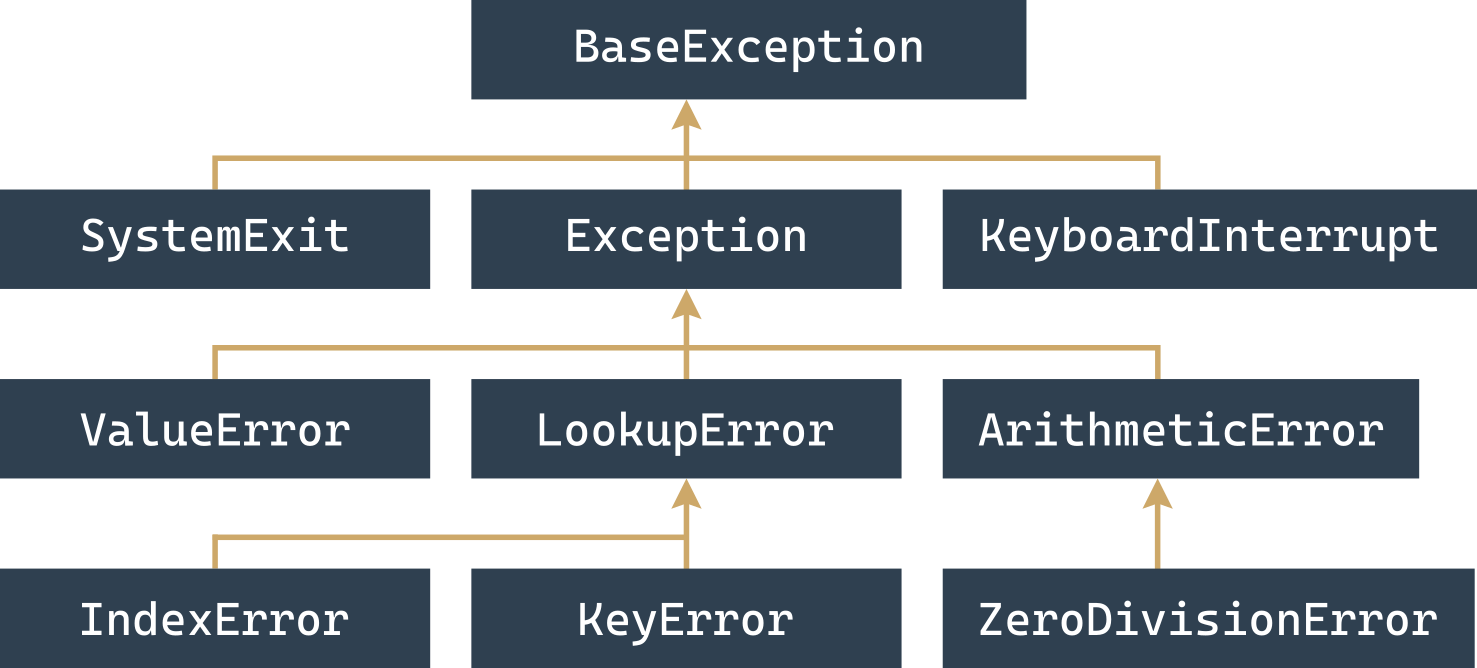

La figura mostra una piccola sezione dell'albero completo delle eccezioni. Iniziamo esaminando l'albero partendo dalla foglia chiamata `ZeroDivisionError`.

Nota bene:

* `ZeroDivisionError` è un caso speciale di una classe di eccezioni più generale chiamata **`ArithmeticError`**.
* `ArithmeticError` è a sua volta un caso speciale di una classe di eccezioni ancora più generale chiamata semplicemente **`Exception`**.
* `Exception` è un caso speciale della classe più astratta in assoluto, chiamata **`BaseException`**.

Possiamo descrivere questa gerarchia nel seguente modo (fai attenzione alla direzione delle frecce: puntano sempre verso l'entità più generale, ovvero risalendo l'albero verso la radice):

$$
\texttt{BaseException}\\
     \uarr\\
 \texttt{Exception}\\
        \uarr\\
\texttt{ArithmeticError}\\
     \uarr\\
\texttt{ZeroDivisionError}\\
$$

Adesso ti mostreremo come funziona in pratica questo meccanismo di generalizzazione. Partiamo con un frammento di codice davvero semplice.

Dai un'occhiata al codice nell'editor: è un ottimo esempio di partenza. Eseguilo per vedere cosa succede.


In [18]:
try:
    y = 1 / 0
except ZeroDivisionError:
    print("Ooopsss...")

print("THE END.")
    

Ooopsss...
THE END.


Ora dai un'occhiata al codice qui sotto:

```python
try:
    y = 1 / 0
except ArithmeticError:
    print("Oooppsss...")
 
print("THE END.")

```

Qualcosa è cambiato: abbiamo sostituito `ZeroDivisionError` con `ArithmeticError`.

Come abbiamo appena visto, `ArithmeticError` è una classe generale che include al suo interno (tra le altre) anche l'eccezione `ZeroDivisionError`. Di conseguenza, l'output del codice rimarrà esattamente lo stesso. Provalo tu stesso per verificare.

Questo significa anche che se sostituissi quel nome con `Exception` o con `BaseException`, il comportamento del programma non cambierebbe: l'errore verrebbe comunque catturato.


## Riassumiamo questa importante regola:

* Ogni eccezione sollevata finisce nel **primo ramo che le corrisponde** (seguendo l'ordine dall'alto verso il basso).
* Il ramo di gestione non deve necessariamente specificare l'eccezione esatta che si è verificata: è sufficiente che l'eccezione indicata nel blocco `except` sia **più generale (più astratta)** rispetto a quella che è stata effettivamente sollevata.

Dai un'occhiata al codice nell'editor. Cosa pensi che succederà in questo caso?

In [19]:
try:
    y = 1 / 0
except ZeroDivisionError:
    print("Zero Division!")
except ArithmeticError:
    print("Arithmetic problem!")

print("THE END.")

Zero Division!
THE END.


Il primo ramo corrispondente è quello che contiene `ZeroDivisionError`. Questo significa che la console mostrerà:

```text
Output
Zero division!
THE END.

```

Cambierebbe qualcosa se scambiassimo di posto i due rami `except`? Proprio come nell'esempio qui sotto:

```python
try:
    y = 1 / 0
except ArithmeticError:
    print("Arithmetic problem!")
except ZeroDivisionError:
    print("Zero Division!")
 
print("THE END.")

```

Il cambiamento è radicale – l'output del codice ora diventa:

```text
Output
Arithmetic problem!
THE END.

```

Come mai, se l'eccezione sollevata è la stessa di prima?
L'eccezione è identica, ma **l'eccezione più generale ora è posizionata per prima** — e di conseguenza catturerà anche tutte le divisioni per zero. Questo significa anche che non c'è alcuna possibilità che un'eccezione riesca a raggiungere il blocco `except ZeroDivisionError:`. Questo ramo è diventato completamente **irraggiungibile**.

Ricorda sempre:

* **L'ordine dei rami è fondamentale!**
* Non inserire mai eccezioni più generali prima di quelle più concrete.
* Farlo renderà queste ultime irraggiungibili e del tutto inutili.
* Inoltre, renderà il tuo codice confuso e incoerente.
* Nota bene: Python **non genererà alcun messaggio di errore** o avviso per segnalarti questo problema di logica.

Se vuoi gestire due o più eccezioni diverse applicando la stessa identica reazione, puoi utilizzare la seguente sintassi:

```python
try:
    :
except (exc1, exc2):
    :

```

Ti basta inserire i nomi di tutte le eccezioni coinvolte in una lista separata da virgole, racchiudendole all'interno di una coppia di **parentesi tonde** (obbligatorie per non confondere l'interprete).


Se un'eccezione viene sollevata all'interno di una funzione, questa può essere gestita in due posti diversi:

1. **All'interno della funzione stessa**, dove si verifica l'errore.
2. **All'esterno della funzione**, nel blocco di codice principale che l'ha chiamata.

Iniziamo ad analizzare la prima variante — dai un'occhiata al codice nell'editor.

In [20]:
def bad_fun(n):
    try:
        return 1 / n
    except ArithmeticError:
        print("Arithmetic Problem!")
    return None

bad_fun(0)

print("THE END.")

Arithmetic Problem!
THE END.


L'eccezione `ZeroDivisionError` (essendo un caso concreto della classe di eccezioni `ArithmeticError`) viene sollevata all'interno della funzione `bad_fun()` e non esce da essa: la funzione stessa se ne prende carico e la gestisce.

Il programma restituisce come output:

```text
Output
Arithmetic problem!
THE END.

```

Tuttavia, è anche possibile fare in modo che l'eccezione si propaghi al di fuori della funzione. Testiamo subito questo comportamento.

Dai un'occhiata al codice qui sotto:

```python
def bad_fun(n):
    return 1 / n
 
try:
    bad_fun(0)
except ArithmeticError:
    print("What happened? An exception was raised!")
 
print("THE END.")

```

In questo caso, il problema deve essere risolto da chi ha invocato la funzione (l'assegnatario della chiamata, o dal chiamante del chiamante, e così via a ritroso).

Il programma restituisce come output:

```text
Output
What happened? An exception was raised!
THE END.

```

> **Nota:** L'eccezione sollevata può superare i confini di funzioni e moduli, risalendo l'intera catena di chiamate (*invocation chain*) alla ricerca di una clausola `except` corrispondente che sia in grado di gestirla.
> Se non viene trovata alcuna clausola di questo tipo lungo il cammino, l'eccezione rimane non gestita e Python risolve il problema nel suo modo standard: interrompendo bruscamente il codice ed emettendo un messaggio diagnostico (il *Traceback*).

Mettiamo un attimo in pausa questa dinamica, perché è il momento di introdurre un'istruzione di Python completamente nuova.

### L'istruzione `raise`

L'istruzione **`raise`** solleva intenzionalmente l'eccezione specificata (che chiameremo `exc`), esattamente come se si fosse verificata in modo naturale durante l'esecuzione:

```python
raise exc

```

Nota: `raise` è una parola chiave (*keyword*) nativa. Questa istruzione ti permette di:

* **Simulare il sollevamento di eccezioni reali** (ad esempio, per testare se la tua strategia di gestione degli errori funziona a dovere prima che si verifichino i casi reali).
* **Gestire parzialmente un'eccezione** all'interno di un blocco e poi rilanciarla per fare in modo che un'altra parte del codice si occupi di completare la gestione (separazione delle responsabilità, o *separation of concerns*).

Dai un'occhiata al codice nell'editor per vedere come puoi utilizzarla in pratica.

In [21]:
def bad_fun(n):
    raise ZeroDivisionError


try:
    bad_fun(0)
except ArithmeticError:
    print("What happened? An error?")

print("THE END.")

What happened? An error?
THE END.


L'output del programma rimane invariato rispetto a prima.

Grazie a questo approccio, puoi testare le tue routine di gestione delle eccezioni in tutta sicurezza, senza essere costretto a forzare il codice a compiere operazioni errate (come una divisione per zero reale) solo per vedere se il blocco reagisce.

#### L'istruzione `raise` senza argomenti

L'istruzione `raise` può essere utilizzata anche nel seguente modo, ovvero omettendo completamente il nome dell'eccezione:

```python
raise

```

Esiste però una **restrizione molto severa**: questa variante di `raise` senza argomenti può essere utilizzata **esclusivamente all'interno di un blocco `except**`. Provare a usarla in qualsiasi altro contesto causerà un errore di sintassi (*RuntimeError*).

Il suo comportamento è semplice: **rilancia immediatamente la stessa identica eccezione** che si sta gestendo in quel momento all'interno del blocco.

Grazie a questa caratteristica, puoi distribuire la gestione di un errore tra diverse parti del codice. Ad esempio, una funzione può intercettare l'eccezione per registrare un log o fare una prima pulizia dei dati, e poi rilanciarla con `raise` per lasciare che sia il programma principale a decidere come notificare l'utente o se interrompere l'esecuzione.

Dai un'occhiata al codice nell'editor ed eseguilo: vedremo subito questo meccanismo in azione.

In [22]:
def bad_fun(n):
    try:
        return n / 0
    except:
        print("I did it again!")
        raise


try:
    bad_fun(0)
except ArithmeticError:
    print("I see!")

print("THE END.")

I did it again!
I see!
THE END.


L'eccezione `ZeroDivisionError` viene sollevata due volte in questo flusso:

* La prima volta avviene all'interno del blocco `try` (causata da una vera e propria divisione per zero).
* La seconda volta viene rilanciata dall'interno del blocco `except` tramite l'istruzione `raise` senza argomenti.

Di conseguenza, il programma produce il seguente output:

```text
Output
I did it again!
I see!
THE END.

```

### L'istruzione `assert`

Questo è il momento ideale per introdurre un'altra istruzione fondamentale di Python, chiamata **`assert`**. Anche in questo caso si tratta di una parola chiave (*keyword*) nativa del linguaggio.

La sua sintassi base è molto lineare:

```python
assert espressione

```

#### Come funziona?

* Valuta l'espressione che le segue (che deve restituire un valore booleano o un suo equivalente).
* Se l'espressione risulta vera (`True`, un valore numerico diverso da zero, una stringa non vuota o qualsiasi oggetto diverso da `None`), l'istruzione **non fa assolutamente nulla** e l'esecuzione prosegue normalmente.
* Se invece l'espressione risulta falsa (`False`, `0`, stringa vuota, `None`, ecc.), l'istruzione **solleva automaticamente e immediatamente un'eccezione di tipo `AssertionError**`. In questo caso si dice che l'asserzione è fallita (*failed assertion*).

#### Come e quando si usa?

* Puoi inserirla nei punti critici del codice in cui vuoi essere **assolutamente sicuro** che i dati non siano palesemente errati, specialmente in contesti dove non hai il pieno controllo sull'input (ad esempio, all'interno di una funzione scritta da te che verrà utilizzata da altri sviluppatori).
* Sollevare un `AssertionError` protegge il tuo programma dal generare risultati non validi o corrotti a valle, evidenziando subito la natura esatta del problema durante la fase di sviluppo.
* **Nota importante:** Le asserzioni non sostituiscono la normale validazione dei dati o la gestione delle eccezioni, ma le integrano. Se la validazione dei dati e il controllo delle eccezioni equivalgono a una guida prudente, l'asserzione svolge il ruolo dell'**airbag**: entra in funzione solo se qualcosa che non doveva assolutamente accadere è andato storto.

Vediamo l'istruzione `assert` in azione. Dai un'occhiata al codice nell'editor ed eseguilo per osservare il suo comportamento.

In [23]:
import math

x = float(input("Enter a number: "))
assert x >= 0.0

x = math.sqrt(x)

print(x)

3.1622776601683795


Il programma scorre senza problemi se inserisci un valore numerico valido maggiore o uguale a zero; in caso contrario, si interrompe bruscamente e mostra in console il seguente messaggio:

```text
Output
Traceback (most recent call last):
File ".main.py", line 4, in <module>
assert x >= 0.0
AssertionError

```

Questo accade perché la condizione `x >= 0.0` è diventata falsa, facendo scattare l'airbag di cui parlavamo prima.

> **Un piccolo trucco utile:** Se vuoi rendere l'asserzione ancora più chiara, puoi aggiungere un messaggio personalizzato separandolo con una virgola, in questo modo:
> `assert x >= 0.0, "Il valore non può essere negativo!"`
> Se l'asserzione fallisce, quel testo verrà mostrato accanto all'errore `AssertionError`.

Con questo abbiamo concluso questa panoramica sugli strumenti fondamentali per gestire e sollevare gli errori in Python. Se sei pronto, possiamo passare alla sezione successiva e iniziare a esplorare l'elenco e le caratteristiche delle singole eccezioni integrate!

# Eccezioni integrate (*Built-in exceptions*)

In questa sezione analizzeremo una selezione delle eccezioni più comuni e utili in Python. Anche se può sembrare strano definire "utile" un evento che rappresenta un fallimento o un errore nel codice, sbagliare è umano e la gestione preventiva dei problemi è una colonna portante della programmazione quotidiana.

Per ciascuna eccezione esamineremo la sua posizione nell'albero gerarchico, una breve descrizione e un frammento di codice pratico che mostra lo scenario in cui viene sollevata.

#### `ArithmeticError`

* **Posizione:** `BaseException` $\leftarrow$ `Exception` $\leftarrow$ `ArithmeticError`
* **Descrizione:** Un'eccezione astratta (classe base) che raggruppa tutti gli errori generati da operazioni aritmetiche, come la divisione per zero o il passaggio di argomenti fuori dal dominio matematico valido.

#### `AssertionError`

* **Posizione:** `BaseException` $\leftarrow$ `Exception` $\leftarrow$ `AssertionError`
* **Descrizione:** Un'eccezione concreta sollevata dall'istruzione `assert` quando la condizione specificata risulta falsa (`False`, `None`, `0` o una stringa vuota).
* **Codice:**

```python
from math import tan, radians
angle = int(input('Inserisci un angolo intero in gradi: '))
 
# Dobbiamo assicurarci che l'angolo sia diverso da 90 + k * 180
assert angle % 180 != 90
print(tan(radians(angle)))

```

#### `BaseException`

* **Posizione:** `BaseException`
* **Descrizione:** La radice assoluta di tutta la gerarchia delle eccezioni di Python. Qualsiasi altra eccezione eredita da questa classe. Di conseguenza, scrivere `except:` (generico) o `except BaseException:` equivale a catturare qualsiasi anomalia, inclusi i segnali di interruzione del sistema.

#### `IndexError`

* **Posizione:** `BaseException` $\leftarrow$ `Exception` $\leftarrow$ `LookupError` $\leftarrow$ `IndexError`
* **Descrizione:** Un'eccezione concreta sollevata quando si tenta di accedere a un elemento inserendo un indice inesistente all'interno di una sequenza (come una lista o una tupla).
* **Codice:**

```python
# Un modo alternativo (ed insolito) per uscire da un ciclo infinito
the_list = [1, 2, 3, 4, 5]
ix = 0
do_it = True
 
while do_it:
    try:
        print(the_list[ix])
        ix += 1
    except IndexError:
        do_it = False
 
print('Fatto')

```

#### `KeyboardInterrupt`

* **Posizione:** `BaseException` $\leftarrow$ `KeyboardInterrupt`
* **Descrizione:** Un'eccezione concreta sollevata quando l'utente invia un segnale di interruzione da tastiera per terminare il programma (il classico `Ctrl-C`). Se questa eccezione viene intercettata e gestita senza terminare esplicitamente il programma, l'esecuzione continuerà normalmente.
* **Nota:** Come si può notare dalla gerarchia, questa classe **non eredita** da `Exception`, ma direttamente da `BaseException`. Questo serve a evitare che un blocco generico `except Exception:` possa bloccare accidentalmente i tentativi dell'utente di interrompere il programma.
* **Codice:**

```python
# Questo codice ignora il tentativo di interruzione tramite Ctrl-C
from time import sleep
 
seconds = 0
 
while True:
    try:
        print(seconds)
        seconds += 1
        sleep(1)
    except KeyboardInterrupt:
        print("Non farlo!")

```

#### `LookupError`

* **Posizione:** `BaseException` $\leftarrow$ `Exception` $\leftarrow$ `LookupError`
* **Descrizione:** Un'eccezione astratta che funge da classe base per tutti gli errori generati da riferimenti o chiavi non validi all'interno di collezioni di dati (liste, dizionari, tuple, ecc.).

#### `MemoryError`

* **Posizione:** `BaseException` $\leftarrow$ `Exception` $\leftarrow$ `MemoryError`
* **Descrizione:** Un'eccezione concreta che scatta quando l'interprete Python esaurisce la memoria RAM disponibile per completare un'operazione.
* **Codice:**

```python
# ATTENZIONE: l'esecuzione di questo codice satura la memoria.
# Non eseguirlo in ambienti di produzione!
string = 'x'
try:
    while True:
        string = string + string
        print(len(string))
except MemoryError:
    print('Non è divertente!')

```

#### `OverflowError`

* **Posizione:** `BaseException` $\leftarrow$ `Exception` $\leftarrow$ `ArithmeticError` $\leftarrow$ `OverflowError`
* **Descrizione:** Un'eccezione concreta che si verifica quando un'operazione matematica produce un numero troppo grande per poter essere memorizzato o gestito dalla struttura dati corrente (molto comune nelle operazioni in virgola mobile della libreria `math`).
* **Codice:**

```python
# Il codice calcola valori crescenti di exp(k)
from math import exp
 
ex = 1
 
try:
    while True:
        print(exp(ex))
        ex *= 2
except OverflowError:
    print('Il numero è troppo grande.')

```

#### `ImportError`

* **Posizione:** `BaseException` $\leftarrow$ `Exception` $\leftarrow$ `StandardError` $\leftarrow$ `ImportError`
* **Descrizione:** Un'eccezione concreta sollevata quando un'operazione di importazione di un modulo o di una libreria fallisce (ad esempio se il modulo non è installato o il nome è errato).
* **Codice:**

```python
try:
    import math
    import time
    import abracadabra  # Questo import fallirà
except ImportError:
    print('Uno degli import è fallito.')

```

#### `KeyError`

* **Posizione:** `BaseException` $\leftarrow$ `Exception` $\leftarrow$ `LookupError` $\leftarrow$ `KeyError`
* **Descrizione:** Un'eccezione concreta sollevata quando si tenta di accedere a un dizionario utilizzando una chiave che non è presente al suo interno.
* **Codice:**

```python
dictionary = {'a': 'b', 'b': 'c', 'c': 'd'}
ch = 'a'
 
try:
    while True:
        ch = dictionary[ch]
        print(ch)
except KeyError:
    print('Chiave inesistente:', ch)

```

Per il momento abbiamo terminato la panoramica sulle eccezioni, ma torneremo ad approfondirle quando affronteremo la programmazione orientata agli oggetti (OOP) in Python.

È fondamentale ricordare che **le eccezioni in Python sono veri e propri oggetti** carichi di informazioni utili (come il messaggio d'errore incorporato o i dettagli del traceback), ma potremo apprezzare appieno questo aspetto solo dopo aver studiato il funzionamento delle classi.